## Laboratorio N°2 - Fundamentos de Aprendizaje Profundo
### Uso de redes convolucionales preentrenadas en visión por computador

Integrantes: Vicente Mieres - Joaquín Saldivia
Fecha: 8 de Diciembre de 2025



In [16]:
# imports
import kagglehub
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


## 1. Introducción

El objetivo de este laboratorio es abordar la tarea clásica de Clasificación de Imágenes , enfocándose específicamente en el reconocimiento de dibujos simples hechos a mano. Utilizaremos el Dataset Quick Draw-10, que consiste en una colección de dibujos de 10 categorías distintas. El desafío principal es clasificar correctamente un boceto en una de estas 10 clases, aprovechando el poder de los modelos convolucionales preentrenados (CNN) para extraer características visuales robustas.

### 1.1 Relevancia

La clasificación de bocetos es una tarea relevante en el campo de la visión por computador, especialmente en aplicaciones de interfaces de usuario (identificación de comandos dibujados), sistemas de búsqueda por contenido visual, y en el desarrollo de herramientas educativas o de accesibilidad.

Para esta tarea, utilizaremos un modelo preentrenado de la familia ResNet (Residual Networks). La elección de ResNet está justificada por su arquitectura, que incorpora conexiones residuales (skip connections), lo que le permite manejar una gran profundidad sin sufrir el problema del vanishing gradient (gradiente desvanecido). Esto resulta en una red con una capacidad de extracción de características superior a modelos menos profundos, lo cual es crucial incluso cuando se aplica la transferencia de aprendizaje en un dominio visual diferente como son los bocetos.

### 1.2 Objetivos

#### 1.2.1 Objetivo General
Aplicar un modelo de Red Neuronal Convolucional (CNN) ResNet preentrenado para resolver un problema de clasificación multiclase sobre un conjunto de datos de bocetos dibujados a mano (Quick Draw-10).

#### 1.2.2 Objetivos Específicos
- Preparar y preprocesar el conjunto de datos Quick Draw-10 para adaptarlo al formato de entrada de la arquitectura ResNet (redimensionado, normalización).
- Utilizar la CNN ResNet preentrenada, ya sea como extractor de características o mediante transferencia de aprendizaje (ajustando las últimas capas).
- Entrenar y evaluar el desempeño del modelo final utilizando métricas apropiadas como Accuracy y Matriz de Confusión.
- Interpretar los resultados y proponer posibles vías de mejora para el sistema de clasificación.

## 2. Descripción del conjunto de datos

El conjunto de datos seleccionado para este laboratorio es el Quick Draw-10, una subselección del vasto proyecto Quick Draw de Google. Este dataset es ideal para evaluar la capacidad de los modelos de visión por computador para clasificar bocetos de alta variabilidad.

`Origen del Dataset:` El Quick Draw Dataset original es una colección de más de 50 millones de dibujos en 345 categorías, recolectados en un juego donde los usuarios dibujaban un objeto en menos de 20 segundos. Para este trabajo, se utiliza una versión reducida y preprocesada, el Quick Draw-10, que contiene solo 10 clases seleccionadas para simplificar el entrenamiento inicial.

`Referencia / Enlace:` El dataset original está disponible en el repositorio de Google Quick Draw. Sin embargo, en particular para este trabajo se optó por el subconjunto disponible en: 
https://www.kaggle.com/datasets/jhunbrianandam/quickdraw10-dataset

A diferencia de la versión original de Google (que usa archivos binarios .bin o .npy), esta versión de Kaggle está organizada en directorios de imágenes (formatos como .png o .jpg), con una carpeta separada para cada una de las 10 clases, lo que facilita su carga utilizando herramientas estándar.


El dataset corresponde a un problema de **clasificación multiclase** con **10 categorías** distintas, conteniendo **3,001 imágenes por clase** para un total de aproximadamente **30,010 imágenes**.

| Índice | Clase (Inglés) | Traducción | Cantidad Imágenes |
| :---: | :--- | :--- | :---: |
| 0 | **Airplane** | Avión | 3,001 |
| 1 | **Angel** | Ángel | 3,001 |
| 2 | **Ant** | Hormiga | 3,001 |
| 3 | **Apple** | Manzana | 3,001 |
| 4 | **Banana** | Banana / Plátano | 3,001 |
| 5 | **Bat** | Murciélago | 3,001 |
| 6 | **Bird** | Pájaro | 3,001 |
| 7 | **Book** | Libro | 3,001 |
| 8 | **Bowtie** | Corbatín / Pajarita | 3,001 |
| 9 | **Broccoli** | Brócoli | 3,001 |

In [ ]:
# Descarga del dataset
path = kagglehub.dataset_download("jhunbrianandam/quickdraw10-dataset")
data_root = os.path.join(path, "data")

# Cargar todo el dataset 
dataset = datasets.ImageFolder(root=data_root)
classes = dataset.classes
print(f"Clases: {classes}")

Clases: ['airplane', 'angel', 'ant', 'apple', 'banana', 'bat', 'bird', 'book', 'bowtie', 'broccoli']


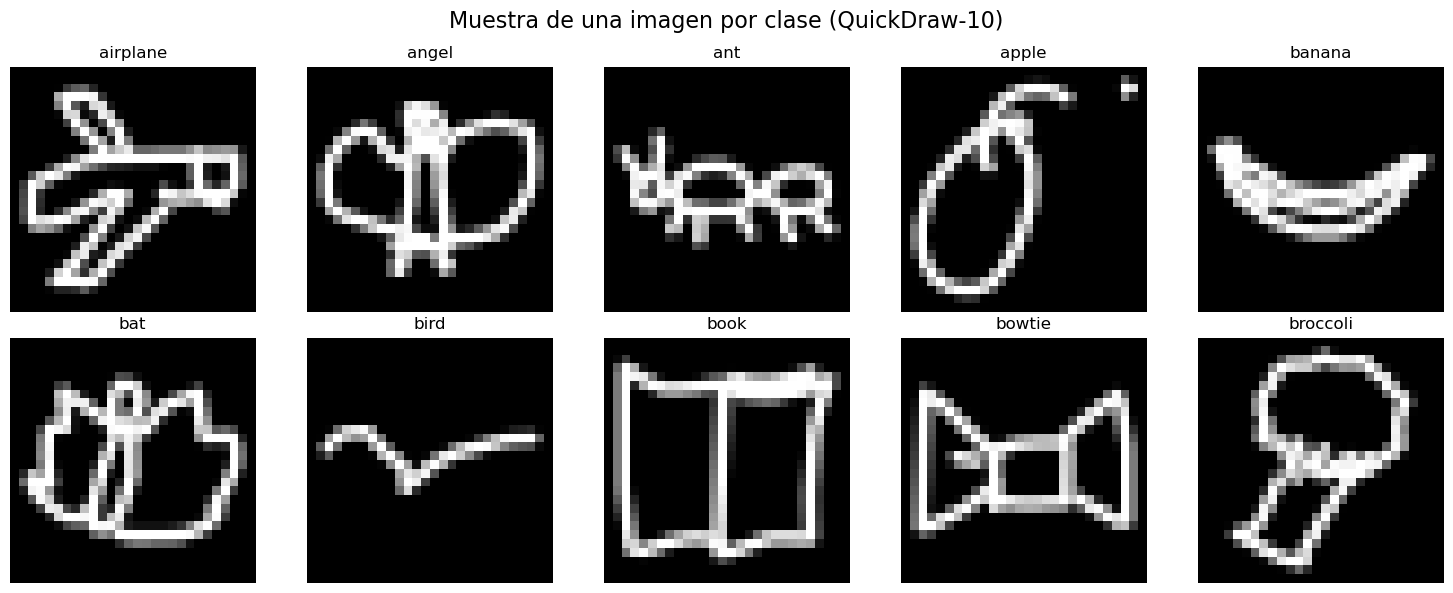

In [18]:
# Ejemplos por clase
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Muestra de una imagen por clase (QuickDraw-10)', fontsize=16)
axes = axes.flatten()

for i, clase_nombre in enumerate(classes):
    class_dir = os.path.join(data_root, clase_nombre)
    
    image_files = sorted(os.listdir(class_dir))
    first_image = image_files[0]
    
    img_path = os.path.join(class_dir, first_image)
    img = Image.open(img_path)

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(clase_nombre)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 3. Preparación y preprocesamiento de los datos

Para alimentar correctamente al modelo preentrenado (ResNet), es necesario realizar una serie de transformaciones a las imágenes originales, así como dividir el conjunto de datos para garantizar una evaluación honesta del desempeño.

### 3.1 Preprocesamiento y Transformaciones

Las imágenes crudas del dataset Quick Draw tienen tamaños variados y usualmente un solo canal (escala de grises). Sin embargo, los modelos preentrenados en ImageNet (como ResNet) tienen requisitos de entrada estrictos. Se aplicó el siguiente pipeline de transformaciones (transforms.Compose):

- Resize (224×224): La arquitectura ResNet fue diseñada y entrenada originalmente con imágenes de entrada de 224×224 píxeles. Mantener esta resolución asegura que las características espaciales se alineen correctamente con los mapas de características aprendidos por la red (los filtros convolucionales).

- Grayscale (3 canales): Aunque los bocetos son inherentemente de 1 canal (blanco y negro), la primera capa convolucional de ResNet espera una entrada de 3 canales (RGB). De esta forma se utlizó num_output_channels=3 para replicar el canal de gris tres veces. Esto permite usar los pesos preentrenados sin modificar la arquitectura de la primera capa.

- Normalización (Mean/Std de ImageNet): Los pesos de la red preentrenada se ajustaron esperando datos que sigan una distribución normal específica. Se restan las medias [0.485, 0.456, 0.406] y se divide por las desviaciones estándar [0.229, 0.224, 0.225]. Omitir este paso dificultaría la convergencia o degradaría el rendimiento, ya que la red recibiría valores "fuera de escala" respecto a lo que "conoce".

In [ ]:
# Definir Transformaciones (ResNet Standard)
# Nota: Usamos la misma transform para train y test para simplificar
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3), # Forzar 3 canales
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

### 3.2 División del Dataset (train/test)

Dado que contamos con un dataset perfectamente equilibrado (~3,000 imágenes por clase), hemos realizado una división estratificada para mantener esta proporción tanto en el entrenamiento como en la prueba.

- Estrategia: Se utilizó la función train_test_split de scikit-learn.

- Proporción: 80% para Entrenamiento y 20% para Prueba (Validación).

- Estratificación: Se utilizó el parámetro stratify=targets. Esto es crucial para asegurar que, si el 10% de los datos totales son "aviones", el set de entrenamiento y el de prueba también tengan exactamente un 10% de "aviones", evitando sesgos.

In [ ]:
# Se vuelve a cargar el dataset pero con transformacion de ResNet
full_dataset = datasets.ImageFolder(root=data_root, transform=transform)
classes = full_dataset.classes
print(f"Clases: {classes}")

# Obtenemos las etiquetas de todo el dataset para poder estratificar
targets = full_dataset.targets 

# Generamos los ÍNDICES de entrenamiento y prueba
train_idx, test_idx = train_test_split(
    np.arange(len(full_dataset)), # Array de 0 a N-1
    test_size=0.2,                # 20% para test
    shuffle=True,
    stratify=targets,             # Mantiene el balance de clases
    random_state=42               # Para reproducibilidad
)

# Creamos los subsets de PyTorch usando esos índices
train_dataset = Subset(full_dataset, train_idx)
test_dataset = Subset(full_dataset, test_idx)

# Creamos los DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Total imágenes: {len(full_dataset)}")
print(f"Entrenamiento: {len(train_dataset)} imágenes")
print(f"Prueba (Test): {len(test_dataset)} imágenes")

Clases: ['airplane', 'angel', 'ant', 'apple', 'banana', 'bat', 'bird', 'book', 'bowtie', 'broccoli']
Total imágenes: 30010
Entrenamiento: 24008 imágenes
Prueba (Test): 6002 imágenes


## 4. Selección y configuración del modelo preentrenado

### 4.1. Modelo Seleccionado: ResNet-34

Para esta tarea de clasificación, hemos seleccionado la arquitectura ResNet-34 (Residual Network de 34 capas). Se utiliza la versión preentrenada con los pesos IMAGENET1K_V1, lo que significa que el modelo ya ha aprendido a extraer características visuales complejas (como bordes, texturas y formas geométricas) a partir de un dataset masivo de 1.000 clases de objetos.

Se eligió ResNet-34 por ser una arquitectura que ofrece un excelente equilibrio entre profundidad y eficiencia computacional.  Su arquitectura basada en bloques residuales evita el problema del desvanecimiento del gradiente, facilitando el entrenamiento de la capa final. Además es menos costosa computacionalmente que modelos masivos (como ResNet-50 o VGG-16), permitiendo iteraciones de entrenamiento rápidas en el entorno de laboratorio.

### 4.2 Estrategia de Transfer Learning

Dada la naturaleza del problema y el tamaño del dataset, hemos optado por utilizar la red como un Extractor de Características Fijo (Feature Extractor). La estrategia implementada consta de tres pasos:

- Congelamiento del Backbone: Se congelan todos los parámetros de la red base (requires_grad = False). Esto preserva el conocimiento adquirido en ImageNet y evita destruir los filtros preentrenados con los gradientes iniciales del nuevo dataset.

- Sustitución del "Head": Se elimina la última capa totalmente conectada (que clasificaba 1000 clases) y se reemplaza por una nueva capa lineal (nn.Linear) que proyecta las características extraídas a nuestras 10 clases específicas.

- Entrenamiento Selectivo: Durante la fase de entrenamiento, el optimizador solo actualizará los pesos de esta nueva última capa.

In [9]:
# 1. Descargar modelo pre-entrenado
model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

# 2. CONGELAR todos los parámetros (Backbone)
for param in model.parameters():
    param.requires_grad = False

# 3. Modificar la capa final (Head)
# Esta es la única capa que tendrá requires_grad = True por defecto al ser creada nueva
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(classes))

model = model.to(device)

## 5. Entrenamiento y experimentos

Esta sección detalla la configuración utilizada para entrenar la capa de clasificación de la ResNet34 y el proceso de monitoreo de las métricas de desempeño.

### 5.1. Configuración del Entrenamiento

Dada nuestra estrategia de Transferencia de Aprendizaje con el backbone de la ResNet congelado, solo se entrenarán los pesos de la capa final (model.fc). Esto permite que el entrenamiento sea rápido y evita la necesidad de un gran número de épocas.


| Parámetro | Valor | Justificación 
| :---: | :--- | :--- |
| OPtimizador | **Adam** | Optimización robusta, rápida y con ajustes adaptativos de la tasa de aprendizaje. 
| Learning Rate | **0.001** | Una tasa de aprendizaje moderada para ajustar la capa lineal sin causar inestabilidad. 
| Función de Pérdida | **CrossEntropyLoss** | Pérdida estándar y obligatoria para problemas de clasificación multiclase. 
| Épocas | **30** | Un número bajo de épocas es suficiente ya que solo se está ajustando una capa pequeña (el head de clasificación). 

### 5.2. Bucle de Entrenamiento y Validación

El bucle de entrenamiento se ejecutó durante 30 épocas, realizando un pase de validación al final de cada una para monitorear el desempeño del modelo en datos no vistos y detectar la aparición de sobreajuste (overfitting).

In [27]:
# Configuración del entrenamiento
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

epochs = 30

# Listas para guardar el historial y luego graficar
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

print("Iniciando entrenamiento...")

for epoch in range(epochs):
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    # Calcular métricas de entrenamiento del epoch
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct / total
    
    # Guardar en historial
    train_loss_history.append(epoch_train_loss)
    train_acc_history.append(epoch_train_acc)

    # --- FASE DE VALIDACIÓN ---
    model.eval() 
    val_loss = 0.0  
    correct_val = 0
    total_val = 0
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() # Acumular pérdida

            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
            # Guardar predicciones del último epoch para análisis posterior
            if epoch == epochs - 1:
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    # Calcular métricas de validación del epoch
    epoch_val_loss = val_loss / len(test_loader)
    epoch_val_acc = 100 * correct_val / total_val
    
    # Guardar en historial
    val_loss_history.append(epoch_val_loss)
    val_acc_history.append(epoch_val_acc) 

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.2f}%")

print("Entrenamiento finalizado.")

Iniciando entrenamiento...
Epoch 1/30 | Train Loss: 0.4101 Acc: 86.75% | Val Loss: 0.4712 Acc: 85.89%
Epoch 2/30 | Train Loss: 0.4074 Acc: 87.17% | Val Loss: 0.4673 Acc: 85.70%
Epoch 3/30 | Train Loss: 0.4081 Acc: 86.97% | Val Loss: 0.4701 Acc: 85.47%
Epoch 4/30 | Train Loss: 0.4131 Acc: 86.87% | Val Loss: 0.4670 Acc: 86.02%
Epoch 5/30 | Train Loss: 0.4047 Acc: 87.13% | Val Loss: 0.4624 Acc: 85.92%
Epoch 6/30 | Train Loss: 0.4138 Acc: 86.63% | Val Loss: 0.4694 Acc: 85.64%
Epoch 7/30 | Train Loss: 0.4085 Acc: 86.84% | Val Loss: 0.4762 Acc: 85.39%
Epoch 8/30 | Train Loss: 0.4100 Acc: 86.90% | Val Loss: 0.4811 Acc: 85.24%
Epoch 9/30 | Train Loss: 0.4096 Acc: 87.28% | Val Loss: 0.4716 Acc: 85.44%
Epoch 10/30 | Train Loss: 0.4150 Acc: 86.68% | Val Loss: 0.4777 Acc: 85.64%
Epoch 11/30 | Train Loss: 0.4097 Acc: 86.85% | Val Loss: 0.4930 Acc: 84.81%
Epoch 12/30 | Train Loss: 0.4071 Acc: 87.00% | Val Loss: 0.4853 Acc: 85.55%
Epoch 13/30 | Train Loss: 0.4075 Acc: 87.13% | Val Loss: 0.4681 Acc: 8

In [31]:
print(f"Precisión en Test Set: {100 * correct_val / total_val:.2f}%")

Precisión en Test Set: 85.50%


### 5.3 Analisis de convergencia y sobreajuste

Para estudiar la convergencia y el sobreajuste se presentan los 2 siguiente gráficos. De estos se puede observar los siguiente:

- Convergencia Rápida: Las curvas se estabilizan rápidamente (alcanzando un plateau o estancamiento) en las primeras épocas. Esto indica que el modelo, al tener el backbone congelado, alcanzó el máximo de su capacidad de aprendizaje para esta configuración en un tiempo muy corto. Esto sugiera que el número de epocas se puede disminuir.

- Generalización y Leve Sobreajuste: Existe una brecha de generalización constante de aproximadamente 1-2% entre las curvas. La precisión de entrenamiento se mantiene en ≈87%, mientras que la de validación se encuentra en ≈85.5%. La pérdida de validación es consistentemente más alta que la de entrenamiento. Esta brecha indica un leve sobreajuste (overfitting), donde el modelo se ajusta mejor a los datos vistos (entrenamiento) que a los datos nuevos (validación), pero la diferencia es lo suficientemente pequeña para considerarse una generalización aceptable.

- Estabilidad: Las fluctuaciones y el ruido observado en la curva de validación sugieren una ligera inestabilidad, probablemente debido a la variabilidad de los batches o una tasa de aprendizaje ligeramente alta.

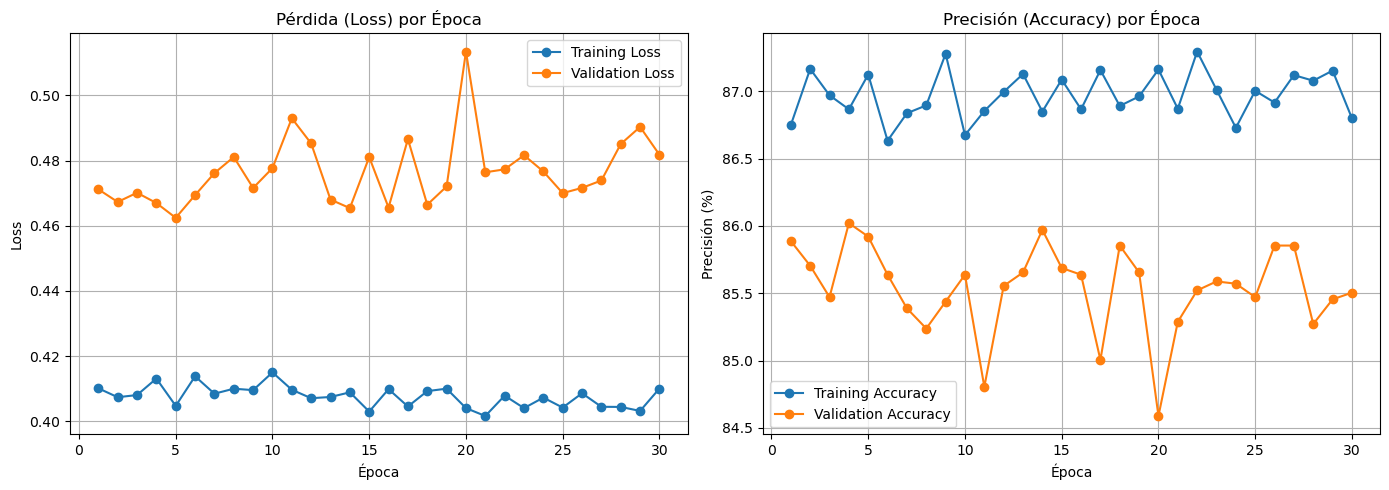

In [28]:
# Crear rango de épocas
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(14, 5))

# --- GRÁFICO 1: PÉRDIDA (LOSS) ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_history, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss_history, label='Validation Loss', marker='o')
plt.title('Pérdida (Loss) por Época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- GRÁFICO 2: PRECISIÓN (ACCURACY) ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_history, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc_history, label='Validation Accuracy', marker='o')
plt.title('Precisión (Accuracy) por Época')
plt.xlabel('Época')
plt.ylabel('Precisión (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 6. Evaluación y análisis de resultados

### 6.1 Metricas de desempeño y matriz de confusión

En esta sección se evalúa el desempeño final del modelo utilizando el conjunto de prueba (Test Set), el cual contiene imágenes que la red nunca vio durante el entrenamiento.

Se utilizó el Accuracy (exactitud) global como métrica principal, complementada con Precision, Recall y F1-Score por clase para detectar desbalances o dificultades específicas.

Accuracy Global: El modelo alcanzó un 85.5% de exactitud en el conjunto de prueba. Esto indica un desempeño general [sólido/aceptable] para una clasificación de 10 clases.

**Análisis por Clase (Classification Report):**

- Clases con mejor desempeño: Las clases *apple* y *bannana* obtuvieron los F1-scores más altos (cercanos a 0.96 y 0.93 respectivamente), probablemente debido a que sus formas son muy distintivas y consistentes.

- Clases con menor desempeño: La clase *bird* presentó el rendimiento general más bajo (F1 de 0.69), afectada principalmente por una baja precisión (0.66). Por otro lado, observando el Recall, vemos que la clase *bat* (0.69) es donde el modelo tiene mayor dificultad para encontrar los objetos, dejando de detectar muchos ejemplos de esta clase (probablemente confundiéndolos con aves por la presencia de alas).

**Matriz de Confusión**

Observando la matriz generada, se pueden destacar tres puntos clave sobre el comportamiento del modelo:

1. Desempeño General (Diagonal Principal) La matriz muestra una diagonal principal claramente definida con colores oscuros, lo que confirma que la mayoría de las predicciones son correctas.

    Clases más robustas: Las clases con mayor número de aciertos son 'book' (589 aciertos de 600), 'banana' (572) y 'apple' (562). Esto sugiere que el modelo aprende muy bien formas geométricas simples y distintivas (rectángulos para libros, curvas para bananas, círculos para manzanas).

2. El "Cluster" de los Alados (La mayor fuente de error) El análisis de los errores fuera de la diagonal revela un patrón muy claro: el modelo tiene graves problemas para distinguir entre objetos que tienen alas o vuelan. Existe una confusión cruzada significativa entre 'bat' (murciélago), 'bird' (pájaro), 'airplane' (avión) y 'angel' (ángel).

    El caso del Murciélago ('bat'): Es la clase con peor desempeño (solo 411 aciertos).

    - 73 murciélagos fueron confundidos con pájaros (bird).

    - 30 fueron confundidos con ángeles (angel).

    - 24 fueron confundidos con aviones (airplane).

    El caso del Pájaro ('bird'):

    - 45 pájaros fueron clasificados erróneamente como murciélagos.

    - 31 pájaros fueron clasificados como aviones y 31 como ángeles.

3. Falsos Positivos en la clase 'Bird' Si observamos la columna de predicción 'bird', vemos que atrae muchos errores de otras clases. El modelo tiende a predecir "pájaro" cuando ve trazos irregulares con extensiones laterales (alas).

    Por ejemplo, 44 aviones reales y 73 murciélagos reales fueron etiquetados incorrectamente como pájaros. Esto indica que la clase 'bird' actúa como una especie de "clase por defecto" para objetos voladores ambiguos.


Reporte de Clasificación:
              precision    recall  f1-score   support

    airplane       0.87      0.84      0.86       600
       angel       0.82      0.82      0.82       600
         ant       0.89      0.87      0.88       600
       apple       0.98      0.94      0.96       601
      banana       0.90      0.95      0.93       600
         bat       0.72      0.69      0.70       600
        bird       0.66      0.72      0.69       601
        book       0.89      0.98      0.93       600
      bowtie       0.91      0.86      0.89       600
    broccoli       0.94      0.87      0.90       600

    accuracy                           0.86      6002
   macro avg       0.86      0.86      0.86      6002
weighted avg       0.86      0.86      0.86      6002



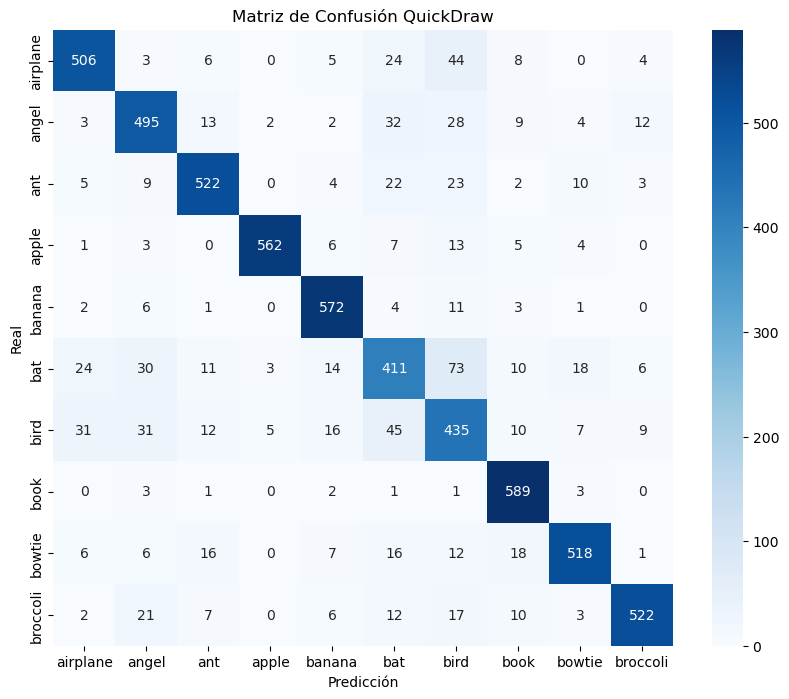

In [32]:
# Generar reporte de texto
print("Reporte de Clasificación:")
print(classification_report(all_labels, all_preds, target_names=classes))

# Matriz de Confusión Visual
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión QuickDraw')
plt.show()

### 6.2 Ejemplos de predicciones correctas e incorrectas

Para evaluar la capacidad de generalización del modelo, se seleccionó y visualizó un conjunto balanceado de predicciones, incluyendo tanto clasificaciones exitosas como errores típicos.

Observaciones:

- Robustez en Aciertos (Títulos Verdes):

    El modelo demuestra una gran capacidad para abstraer formas. Por ejemplo, identifica correctamente la clase 'bird' o 'brocoli' a pesar de la simplicidad extrema de los trazos o variaciones en la orientación. Esto indica que la red ha aprendido características invariantes y no memorizó simplemente píxeles.

- Análisis de Errores (Títulos Rojos):

    Confusiones Visuales Lógicas: La mayoría de los errores son semánticamente razonables. Se observa un casos donde un 'bat' (murciélago) se clasifica como 'ant' debido a la forma en que fue dibujado, en este caso alargado, utilizando casi todo el marco del dibujo (último ejemplo).

Recolectando muestras balanceadas...


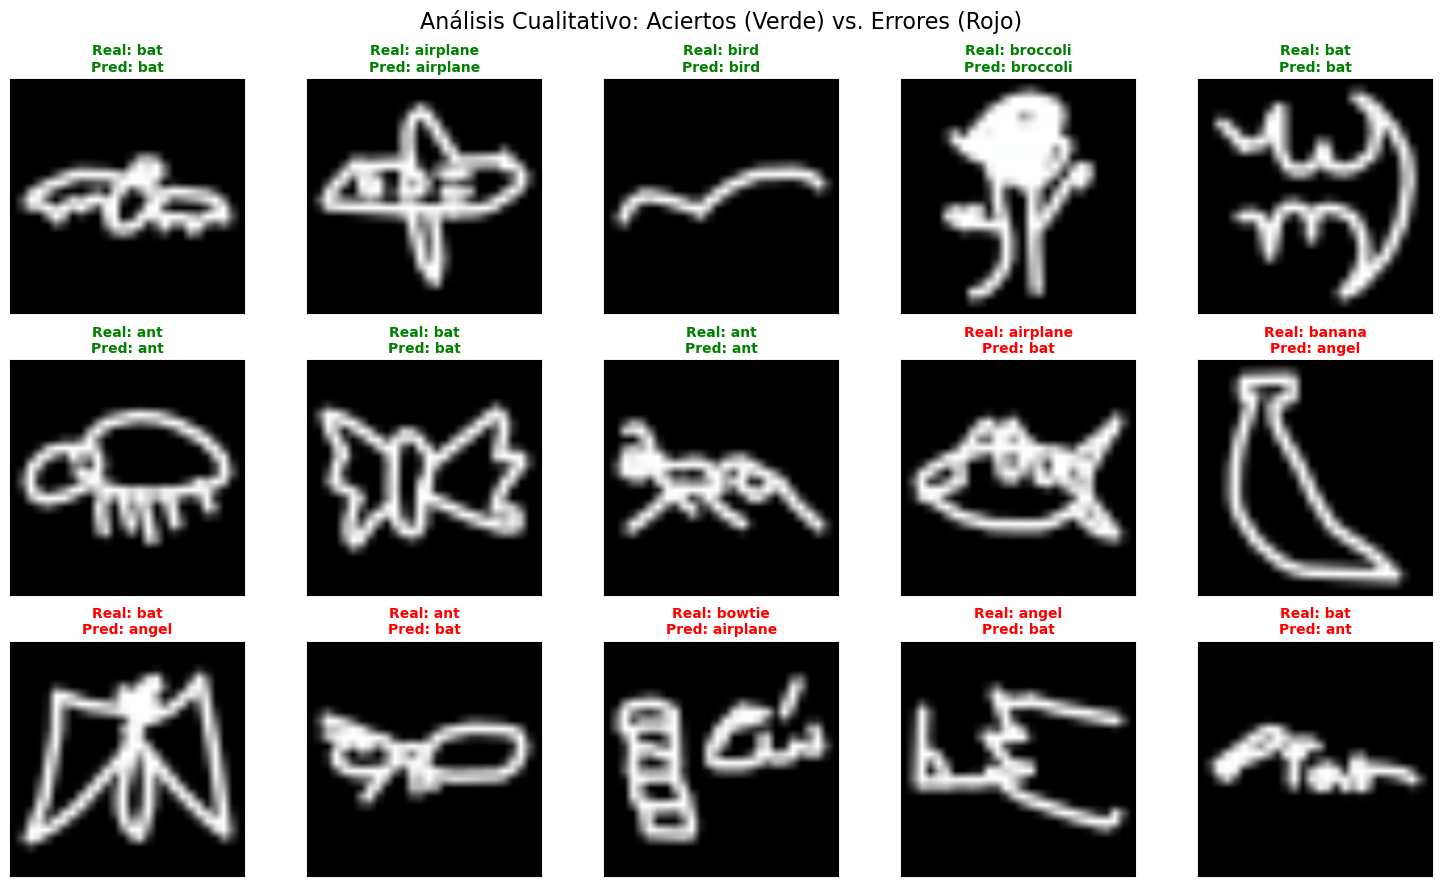

In [ ]:
def imshow(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

model.eval()

# Listas para guardar ejemplos
correct_samples = []
incorrect_samples = []

# Configuración: Cuántos queremos de cada uno
num_correct_needed = 8
num_incorrect_needed = 7

print("Recolectando muestras balanceadas...")

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        # Iterar sobre el batch actual
        for i in range(len(labels)):
            img = images[i].cpu().numpy()
            lbl = labels[i].cpu().item()
            pred = preds[i].cpu().item()
            
            # Si acertó y nos faltan correctos, guardar
            if lbl == pred and len(correct_samples) < num_correct_needed:
                correct_samples.append((img, lbl, pred))
                
            # Si falló y nos faltan incorrectos, guardar
            elif lbl != pred and len(incorrect_samples) < num_incorrect_needed:
                incorrect_samples.append((img, lbl, pred))
                
            # Si ya tenemos suficientes de ambos, paramos
            if len(correct_samples) == num_correct_needed and len(incorrect_samples) == num_incorrect_needed:
                break
        
        if len(correct_samples) == num_correct_needed and len(incorrect_samples) == num_incorrect_needed:
            break

# Combinar listas
all_samples = correct_samples + incorrect_samples

# Graficar
fig = plt.figure(figsize=(15, 9))
fig.suptitle("Análisis Cualitativo: Aciertos (Verde) vs. Errores (Rojo)", fontsize=16)

for idx, (img, lbl, pred) in enumerate(all_samples):
    ax = fig.add_subplot(3, 5, idx+1, xticks=[], yticks=[])
    plt.imshow(imshow(img))
    
    real_class = classes[lbl]
    pred_class = classes[pred]
    
    color = 'green' if lbl == pred else 'red'
    
    ax.set_title(f"Real: {real_class}\nPred: {pred_class}", color=color, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 6.3 Comentarios finales

El resultado obtenido (86% de Accuracy) es altamente satisfactorio. Valida la eficacia del Transfer Learning con ResNet-34, demostrando que una red entrenada en imágenes reales puede extraer características robustas de bocetos abstractos de forma eficiente y con rápida convergencia.

Problemas Observados:

- Similitud en clases: La principal limitación es la confusión entre clases que comparten estructuras visuales dominantes, específicamente objetos con "alas" ('bird', 'bat', 'angel' y 'airplane'). La red identifica la forma general pero falla en los detalles distintivos.

- Ruido en los Datos: La naturaleza de los bocetos rápidos introduce ambigüedad; algunos dibujos son incompletos o garabatos irreconocibles, lo que establece un límite natural a la precisión que el modelo puede alcanzar.


## 7. Conclusión

En este laboratorio se implementó un sistema de clasificación de imágenes para el dataset Quick Draw-10 utilizando la arquitectura ResNet-34 mediante la técnica de Transfer Learning (extracción de características).

Los resultados obtenidos fueron satisfactorios, alcanzando una exactitud (Accuracy) del 86% en el conjunto de prueba. Esto demuestra que los modelos preentrenados en imágenes naturales (ImageNet) poseen filtros lo suficientemente robustos para generalizar a dominios visuales abstractos como los bocetos a mano alzada. El modelo convergió rápidamente, identificando con alta precisión formas geométricas claras (como manzanas o libros), aunque mostró dificultades consistentes al diferenciar clases con morfologías compartida, específicamente aquellas con estructuras de alas (avión, ángel, pájaro, murciélago).

Además, es posible identificar limitaciones en la metodología utilizada. En primer lugar la *Capacidad de Adaptación* de la red, puesto que al utiliza la red exclusivamente como extractor de características, se limita la capacidad del modelo para aprender patrones específicos de los trazos. Por otro lado la *Calidad del Dataset* se presenta como una limitación, pueto que esta contiene una cantidad considerable de ruido, presentando ejemplo practicamente irreconocibles.

Finalmente, como suguerencias para trabajos futuros, es posible mencionar una limpieza del dataset, con el objetivo de filtrar muestras con poca información, o incluso realizar un Fine-tunning en las ultimas capas convolucionales de la red y re-entrenarlas con otros hiperparámetros.